# LSTM-GCN with Rolling Pearson Correlation Graphs

This notebook implements an LSTM-GCN model that uses **rolling Pearson correlation graphs** instead of a single static precomputed graph.

**Key differences from the original LSTM-GCN:**
- Each sample gets its own adjacency matrix computed from rolling returns correlation
- Correlation lookback window is a hyperparameter (20, 40, 60 time steps)
- Correlation threshold (tau) is also configurable

**Output:** Same performance metrics as run_all_strategies.ipynb

## 1. Setup

In [1]:
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded spektral

In [2]:
import os
import sys

# Set working directory
# For Colab:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/4YP-main')

# # For local:
# os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/4YP-main


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from empyrical import (
    sharpe_ratio,
    sortino_ratio,
    max_drawdown,
    annual_return,
    annual_volatility,
    calmar_ratio,
)

# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Configuration

In [4]:
# Training/Test Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023
TEST_WINDOW_SIZE = 6  # years

VOL_TARGET = 0.15  # 15% volatility target for normalization

# Rolling Pearson Configuration
CORRELATION_LOOKBACK = 20  # Options: 20, 40, 60
CORRELATION_THRESHOLD = 0.45  # Options: 0.3, 0.4, 0.5, 0.6

# Model Configuration
TOTAL_TIME_STEPS = 20
TRAIN_VALID_RATIO = 0.8
NUM_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 25

print(f"Train: {TRAIN_START}-{TEST_START}")
print(f"Test:  {TEST_START}-{TEST_END}")
print(f"\nRolling Pearson Configuration:")
print(f"  Correlation lookback: {CORRELATION_LOOKBACK} time steps")
print(f"  Correlation threshold: {CORRELATION_THRESHOLD}")

Train: 2011-2017
Test:  2017-2023

Rolling Pearson Configuration:
  Correlation lookback: 20 time steps
  Correlation threshold: 0.45


## 3. Helper Functions

In [5]:
def load_captured_returns(results_path):
    """Load captured returns from CSV file."""
    df = pd.read_csv(results_path)
    df['time'] = pd.to_datetime(df['time'])
    return df


def calc_daily_returns(df, returns_col='captured_returns'):
    """Aggregate daily returns across all tickers."""
    num_tickers = df['identifier'].nunique()
    daily_ret = df.groupby('time')[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()


def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    """Scale returns to target annualized volatility."""
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        scale_factor = target_vol / current_vol
        return daily_returns * scale_factor
    return daily_returns


def calc_metrics(daily_returns, name="Strategy"):
    """Calculate all performance metrics."""
    metrics = {
        'Strategy': name,
        'E[Ret.]': annual_return(daily_returns),
        'Vol.': annual_volatility(daily_returns),
        'Sharpe': sharpe_ratio(daily_returns),
        'Sortino': sortino_ratio(daily_returns),
        'Max DD': -max_drawdown(daily_returns),
        'Calmar': calmar_ratio(daily_returns),
        'Hit Rate': (daily_returns > 0).mean(),
        'Avg P/L': daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }
    return metrics


def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    """Calculate metrics with volatility-normalized returns."""
    scaled_returns = calc_vol_scaled_returns(daily_returns, target_vol)
    metrics = calc_metrics(scaled_returns, name + " (Vol-Norm)")
    return metrics, scaled_returns


def display_metrics(metrics_dict):
    """Display metrics in a formatted table."""
    df = pd.DataFrame([metrics_dict])
    df = df.set_index('Strategy')
    
    # Format percentages
    for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.2%}")
    
    # Format ratios
    for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.3f}")
    
    display(df)
    return df


def calc_yearly_sharpes(daily_returns):
    """Calculate Sharpe ratio by year."""
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly


def plot_results(daily_returns_dict, title="Strategy Comparison"):
    """Plot cumulative returns, drawdown, and rolling Sharpe."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))
    
    # 1. Cumulative Returns
    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title('Cumulative Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # 2. Drawdown
    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title('Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # 3. Rolling 252-day Sharpe
    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rolling_sharpe = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax3.set_title('Rolling 252-Day Sharpe Ratio')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # 4. Yearly Sharpe Comparison
    ax4 = axes[1, 1]
    yearly_data = {}
    for name, returns in daily_returns_dict.items():
        yearly_data[name] = calc_yearly_sharpes(returns)
    
    yearly_df = pd.DataFrame(yearly_data)
    yearly_df.plot(kind='bar', ax=ax4, width=0.8)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax4.set_title('Yearly Sharpe Ratios')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Data Loading and Preparation

In [6]:
# Load feature data
features_path = "data/straddle_features/features.csv"
df = pd.read_csv(features_path)
df['date'] = pd.to_datetime(df['date'])
# Note: Do NOT set date as index - ModelFeatures expects it as a column

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Tickers: {df['ticker'].nunique()}")
print(f"\nColumns: {df.columns.tolist()}")

Loaded 274384 rows
Date range: 2010-07-01 00:00:00 to 2023-08-30 00:00:00
Tickers: 88

Columns: ['Date', 'straddle_price', 'exdate', 'moneyness', 'daily_returns', 'daily_vol', 'target_returns', 'norm_daily_return', 'norm_monthly_return', 'norm_quarterly_return', 'norm_biannual_return', 'norm_annual_return', 'macd_2_8', 'macd_4_16', 'macd_8_32', 'day_of_week', 'day_of_month', 'month_of_year', 'year', 'log_moneyness', 'time_to_expiry', 'ticker', 'date']


In [7]:
# Import the rolling graph features class
from gml.graph_model_inputs import RollingGraphModelFeatures

# Create the feature generator with rolling Pearson configuration
rolling_features = RollingGraphModelFeatures(
    df=df,
    total_time_steps=TOTAL_TIME_STEPS,
    correlation_lookback=CORRELATION_LOOKBACK,
    correlation_threshold=CORRELATION_THRESHOLD,
    returns_column="daily_returns",
    start_boundary=TRAIN_START,
    test_boundary=TEST_START,
    test_end=TEST_END,
    train_valid_ratio=TRAIN_VALID_RATIO,
    split_tickers_individually=True,
    time_features=False,
)

print("Feature generator created.")

no lags


train _batch
After final stacking and culling:
inputs.shape: (57, 88, 20, 10)
outputs.shape: (57, 88, 20, 1)
active_entries.shape: (57, 88, 20, 1)
identifier.shape: (57, 88, 20, 1)
date.shape: (57, 88, 20, 1)
adjacency.shape: (57, 88, 88)


valid _batch
After final stacking and culling:
inputs.shape: (14, 88, 20, 10)
outputs.shape: (14, 88, 20, 1)
active_entries.shape: (14, 88, 20, 1)
identifier.shape: (14, 88, 20, 1)
date.shape: (14, 88, 20, 1)
adjacency.shape: (14, 88, 88)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)
adjacency.shape: (70, 88, 88)


test sliding _batch
After final stacking and culling:
inputs.shape: (1400, 88, 20, 10)
outputs.shape: (1400, 88, 20, 1)
active_entries.shape: (1400, 88, 20, 1)
identifier.shape: (1400, 88, 20, 1)
date.shape: (1400, 88, 20, 1)
adjacency.shape: (1400, 88, 88)
Feature ge

In [8]:
# Generate datasets with rolling adjacency matrices
datasets = rolling_features.make_rolling_graph_dataset(
    #=False,
    sliding_window=True,  # Use sliding window for test
)

train_data = datasets['train']
valid_data = datasets['valid']
test_data = datasets['test']

print("\nTraining data:")
print(f"  inputs: {train_data['inputs'].shape}")
print(f"  outputs: {train_data['outputs'].shape}")
print(f"  adjacency: {train_data['adjacency'].shape}")

print("\nValidation data:")
print(f"  inputs: {valid_data['inputs'].shape}")
print(f"  outputs: {valid_data['outputs'].shape}")
print(f"  adjacency: {valid_data['adjacency'].shape}")

print("\nTest data:")
print(f"  inputs: {test_data['inputs'].shape}")
print(f"  outputs: {test_data['outputs'].shape}")
print(f"  adjacency: {test_data['adjacency'].shape}")


Training data:
  inputs: (57, 88, 20, 10)
  outputs: (57, 88, 20, 1)
  adjacency: (57, 88, 88)

Validation data:
  inputs: (14, 88, 20, 10)
  outputs: (14, 88, 20, 1)
  adjacency: (14, 88, 88)

Test data:
  inputs: (1400, 88, 20, 10)
  outputs: (1400, 88, 20, 1)
  adjacency: (1400, 88, 88)


## 5. Model Definition

In [9]:
from tensorflow import keras
from tensorflow.keras import layers
from gml.graph_model_2 import DynamicGraphConvolution, GraphSharpeLoss

def build_rolling_lstm_gcn_model(
    num_tickers,
    time_steps,
    input_size,
    hidden_layer_size=10,
    gcn_units=16,
    dropout_rate=0.4,
    learning_rate=0.001,
    max_gradient_norm=0.01,
    num_gcn_layers=2,
):
    """
    Build LSTM-GCN model with dynamic (per-sample) adjacency matrices.
    
    Args:
        num_tickers: Number of stocks/nodes (88)
        time_steps: Number of time steps per sample (20)
        input_size: Number of input features (10)
        hidden_layer_size: LSTM hidden units
        gcn_units: GCN output units
        dropout_rate: LSTM dropout
        learning_rate: Adam learning rate
        max_gradient_norm: Gradient clipping norm
        num_gcn_layers: Number of GCN layers (1 or 2)
    
    Returns:
        Compiled Keras model with two inputs: [features, adjacency]
    """
    # Input layers
    feature_input = keras.Input(
        shape=(num_tickers, time_steps, input_size),
        name="features"
    )
    adjacency_input = keras.Input(
        shape=(num_tickers, num_tickers),
        name="adjacency"
    )
    
    # Shared LSTM for all tickers
    shared_lstm = layers.LSTM(
        hidden_layer_size,
        return_sequences=True,
        dropout=dropout_rate,
        activation="tanh",
        recurrent_activation="sigmoid",
        name="shared_lstm"
    )
    
    # Process each ticker through shared LSTM
    lstm_outputs = []
    for i in range(num_tickers):
        ticker_slice = layers.Lambda(lambda x, idx=i: x[:, idx, :, :])(feature_input)
        ticker_output = shared_lstm(ticker_slice)
        lstm_outputs.append(ticker_output)
    
    # Stack LSTM outputs: (batch, time_steps, num_tickers, hidden)
    stacked_lstm = layers.Lambda(lambda tensors: tf.stack(tensors, axis=2))(lstm_outputs)
    print(f"Stacked LSTM shape: {stacked_lstm.shape}")
    
    # Apply Dynamic GCN layers
    gcn_output = DynamicGraphConvolution(units=gcn_units)([stacked_lstm, adjacency_input])
    gcn_output = layers.ReLU()(gcn_output)
    
    if num_gcn_layers == 2:
        gcn_output = DynamicGraphConvolution(units=gcn_units)([gcn_output, adjacency_input])
        gcn_output = layers.ReLU()(gcn_output)
    
    print(f"GCN output shape: {gcn_output.shape}")
    
    # Residual connection
    residual = layers.TimeDistributed(
        layers.TimeDistributed(
            keras.layers.Dense(gcn_units, activation="linear")
        )
    )(stacked_lstm)
    
    x = layers.Add()([gcn_output, residual])
    
    # Output layer
    output = layers.TimeDistributed(
        layers.TimeDistributed(
            keras.layers.Dense(
                1,
                activation=tf.nn.tanh,
                kernel_constraint=keras.constraints.max_norm(3),
            )
        )
    )(x)
    
    # Permute to match label shape: (batch, num_tickers, time_steps, 1)
    output = layers.Permute((2, 1, 3))(output)
    
    # Create model
    model = keras.Model(
        inputs=[feature_input, adjacency_input],
        outputs=output
    )
    
    # Compile
    adam = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=max_gradient_norm)
    sharpe_loss = GraphSharpeLoss(output_size=1).call
    
    model.compile(
        loss=sharpe_loss,
        optimizer=adam,
    )
    
    return model

LOADING graph_model_2.py - VERSION WITH run_trial DEBUG PRINTS


In [10]:
# Build the model
num_tickers = train_data['inputs'].shape[1]
time_steps = train_data['inputs'].shape[2]
input_size = train_data['inputs'].shape[3]

print(f"Building model with:")
print(f"  num_tickers: {num_tickers}")
print(f"  time_steps: {time_steps}")
print(f"  input_size: {input_size}")

model = build_rolling_lstm_gcn_model(
    num_tickers=num_tickers,
    time_steps=time_steps,
    input_size=input_size,
    hidden_layer_size=10,
    gcn_units=16,
    dropout_rate=0.4,
    learning_rate=0.001,
    max_gradient_norm=0.01,
    num_gcn_layers=2,
)

model.summary()

Building model with:
  num_tickers: 88
  time_steps: 20
  input_size: 10
Stacked LSTM shape: (None, 20, 88, 10)
GCN output shape: (None, 20, 88, 16)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 88, 20,    │          0 │ -                 │
│ (InputLayer)        │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_13 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_14 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_15 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_16 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_17 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_18 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_19 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_20 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_21 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_22 (Lambda)  │ (None, 20, 10)    │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,481 (5.79 KB)

 Trainable params: 1,481 (5.79 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

In [11]:
# Prepare training data
X_train = [train_data['inputs'], train_data['adjacency']]
y_train = train_data['outputs']

X_valid = [valid_data['inputs'], valid_data['adjacency']]
y_valid = valid_data['outputs']

print(f"Training samples: {train_data['inputs'].shape[0]}")
print(f"Validation samples: {valid_data['inputs'].shape[0]}")

Training samples: 57
Validation samples: 14


In [12]:
# Training callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("="*60)
print("Training LSTM-GCN with Rolling Pearson Graphs")
print(f"  Correlation lookback: {CORRELATION_LOOKBACK}")
print(f"  Correlation threshold: {CORRELATION_THRESHOLD}")
print("="*60)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=NUM_EPOCHS,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

Training LSTM-GCN with Rolling Pearson Graphs
  Correlation lookback: 20
  Correlation threshold: 0.45
Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 247s 54s/step - loss: 0.2241 - val_loss: -0.0437
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step - loss: 0.2143 - val_loss: -0.2041
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step - loss: 0.0393 - val_loss: -0.3360
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step - loss: -0.0024 - val_loss: -0.4354
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step - loss: -0.1681 - val_loss: -0.5077
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step - loss: -0.2208 - val_loss: -0.5649
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step - loss: -0.3241 - val_loss: -0.6084
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step - loss: -0.3915 - val_loss: -0.6390
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step - loss: -0.4344 - val_loss: -0.6661
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step - loss: -0.4488 - val_loss: -0.6911
Epoch 11/300
2/2 ━━━━━━━━━━━━

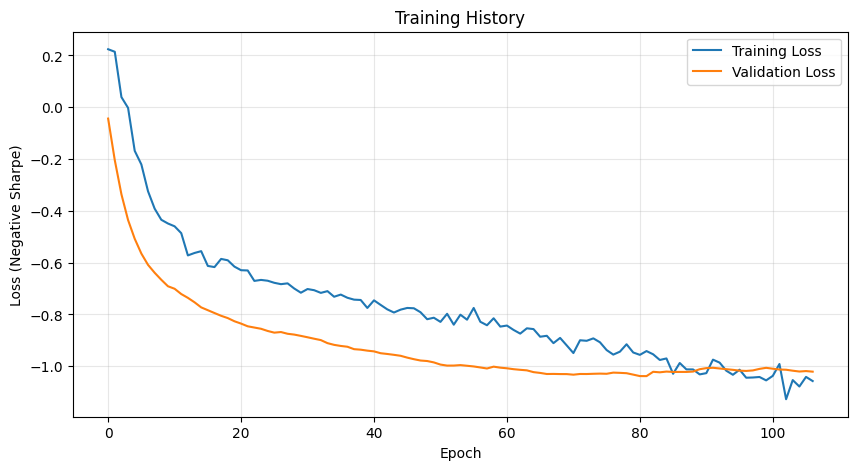

In [13]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Negative Sharpe)')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Evaluation

In [14]:
# Generate predictions on test set
X_test = [test_data['inputs'], test_data['adjacency']]
predictions = model.predict(X_test)

print(f"Predictions shape: {predictions.shape}")
print(f"Test outputs shape: {test_data['outputs'].shape}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step 
Predictions shape: (1400, 88, 20, 1)
Test outputs shape: (1400, 88, 20, 1)


In [15]:
# Calculate captured returns
# Flatten predictions and outputs
positions = predictions.reshape(-1)
returns = test_data['outputs'].reshape(-1)
captured_returns = positions * returns

# Get dates and identifiers for each prediction
dates = test_data['date'].reshape(-1)
identifiers = test_data['identifier'].reshape(-1)

# Create results dataframe
results_df = pd.DataFrame({
    'time': dates,
    'identifier': identifiers,
    'position': positions,
    'returns': returns,
    'captured_returns': captured_returns,
})

results_df['time'] = pd.to_datetime(results_df['time'])
results_df = results_df[results_df['identifier'] != '0']  # Remove padding
results_df = results_df[results_df['time'].dt.year >= TEST_START]

print(f"Results: {len(results_df)} rows")
results_df.head()

Results: 2447280 rows


,time,identifier,position,returns,captured_returns
19,2017-01-03,AAPL,0.014386,-0.009874,-0.000142
39,2017-01-03,ABT,-0.356923,-0.002442,0.000872
59,2017-01-03,ACN,-0.046369,-0.008236,0.000382
79,2017-01-03,ADBE,-0.098036,-0.010764,0.001055
99,2017-01-03,AIG,-0.295987,-0.003832,0.001134


In [16]:
# Calculate daily returns
daily_returns = calc_daily_returns(results_df)

# Raw metrics
print("\n" + "="*60)
print("LSTM-GCN Rolling Pearson Results (Raw)")
print(f"  Correlation lookback: {CORRELATION_LOOKBACK}")
print(f"  Correlation threshold: {CORRELATION_THRESHOLD}")
print("="*60)

metrics_raw = calc_metrics(daily_returns, "LSTM-GCN Rolling")
display_metrics(metrics_raw)

# Vol-normalized metrics
print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
metrics_norm, scaled_returns = calc_metrics_vol_normalized(daily_returns, "LSTM-GCN Rolling", VOL_TARGET)
display_metrics(metrics_norm)

# Yearly Sharpes
print("\nYearly Sharpe Ratios:")
yearly_sharpes = calc_yearly_sharpes(daily_returns)
for year, sharpe in yearly_sharpes.items():
    print(f"  {year}: {sharpe:.4f}")


LSTM-GCN Rolling Pearson Results (Raw)
  Correlation lookback: 20
  Correlation threshold: 0.45


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN Rolling,50.12%,44.78%,1.135,1.550,51.79%,0.968,59.71%,0.838



Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN Rolling (Vol-Norm),17.23%,15.00%,1.135,1.550,20.18%,0.854,59.71%,0.838



Yearly Sharpe Ratios:
  2017: 3.5474
  2018: -0.2680
  2019: 1.9747
  2020: 0.6392
  2021: 1.3928
  2022: 0.5640


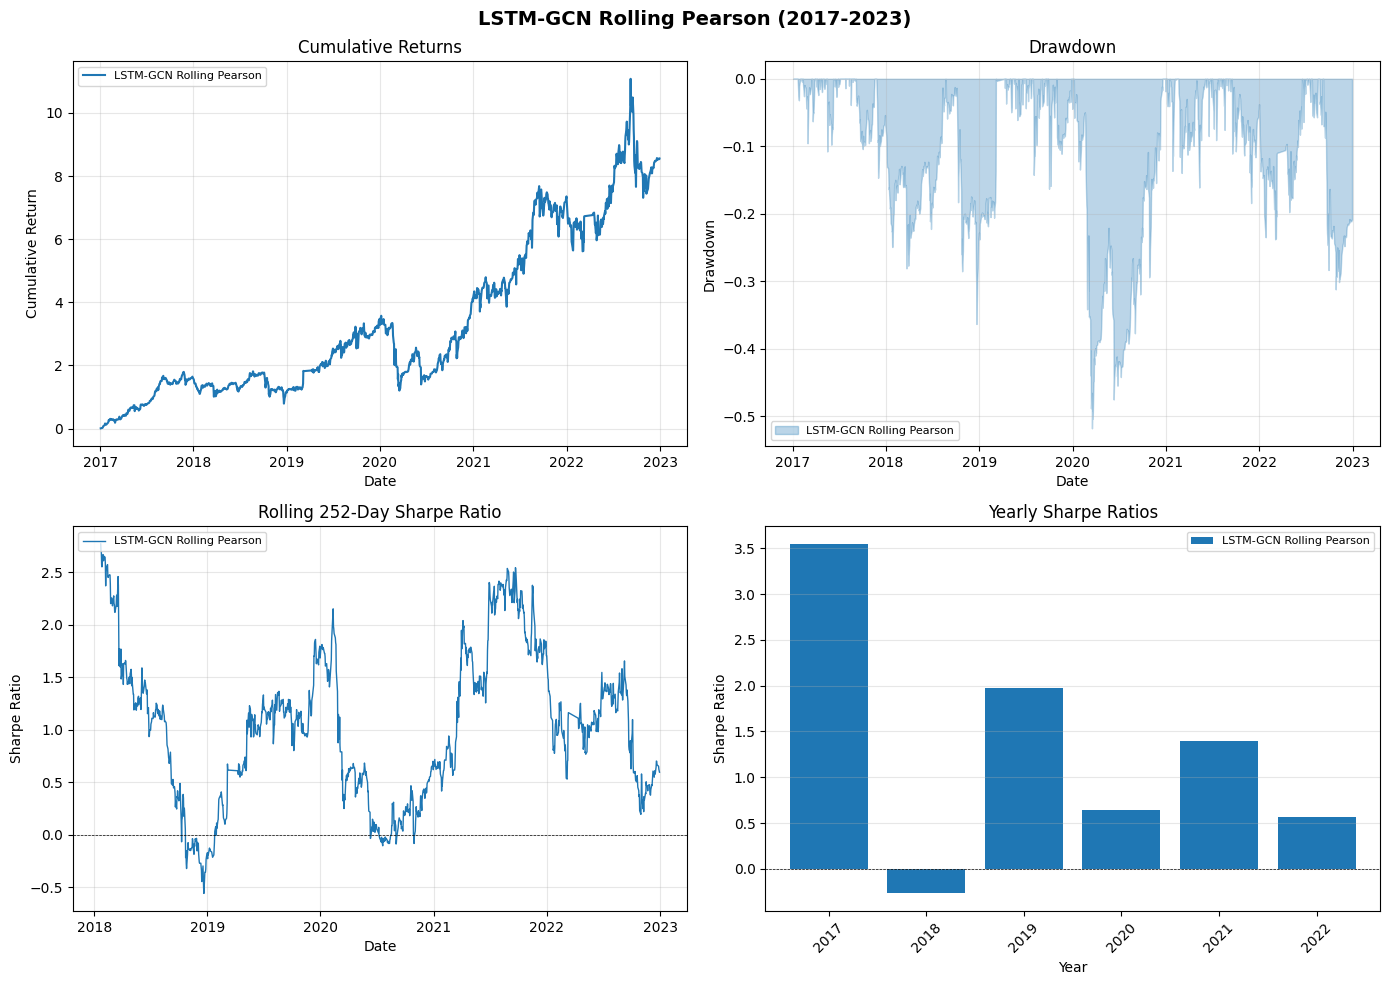

In [17]:
# Plot results
all_daily_returns = {'LSTM-GCN Rolling Pearson': daily_returns}
plot_results(all_daily_returns, f"LSTM-GCN Rolling Pearson ({TEST_START}-{TEST_END})")

## 8. Graph Visualization and Analysis

In [18]:
from settings.default import ALL_TICKERS

def plot_adjacency_heatmap(adj, title, tickers=None):
    """Plot single adjacency matrix as heatmap."""
    plt.figure(figsize=(12, 10))
    if tickers is not None:
        sns.heatmap(adj, xticklabels=tickers, yticklabels=tickers, cmap='YlOrRd')
        plt.xticks(rotation=90, fontsize=6)
        plt.yticks(fontsize=6)
    else:
        sns.heatmap(adj, cmap='YlOrRd')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_adjacent_graphs(adjacencies, dates, start_idx=0):
    """Plot 4 consecutive adjacency matrices side-by-side."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    for i, ax in enumerate(axes.flat):
        idx = start_idx + i
        if idx < len(adjacencies):
            sns.heatmap(adjacencies[idx], ax=ax, cmap='YlOrRd', cbar=True)
            ax.set_title(f"Window {idx} ({dates[idx]})")
        else:
            ax.set_visible(False)
    plt.suptitle(f"Rolling Adjacency Matrices (Windows {start_idx} to {start_idx+3})")
    plt.tight_layout()
    plt.show()


def plot_graph_diff(adj1, adj2, title):
    """Visualize edge changes between two graphs."""
    diff = adj2 - adj1
    plt.figure(figsize=(12, 10))
    sns.heatmap(diff, cmap='RdBu', center=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_edge_statistics(adjacencies):
    """Track number of edges over time."""
    num_edges = [(adj > 0).sum() / 2 for adj in adjacencies]
    
    plt.figure(figsize=(14, 4))
    plt.plot(num_edges, linewidth=0.8)
    plt.xlabel('Window Index')
    plt.ylabel('Number of Edges')
    plt.title('Graph Connectivity Over Time')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Edge statistics:")
    print(f"  Mean: {np.mean(num_edges):.1f}")
    print(f"  Std: {np.std(num_edges):.1f}")
    print(f"  Min: {np.min(num_edges):.0f}")
    print(f"  Max: {np.max(num_edges):.0f}")

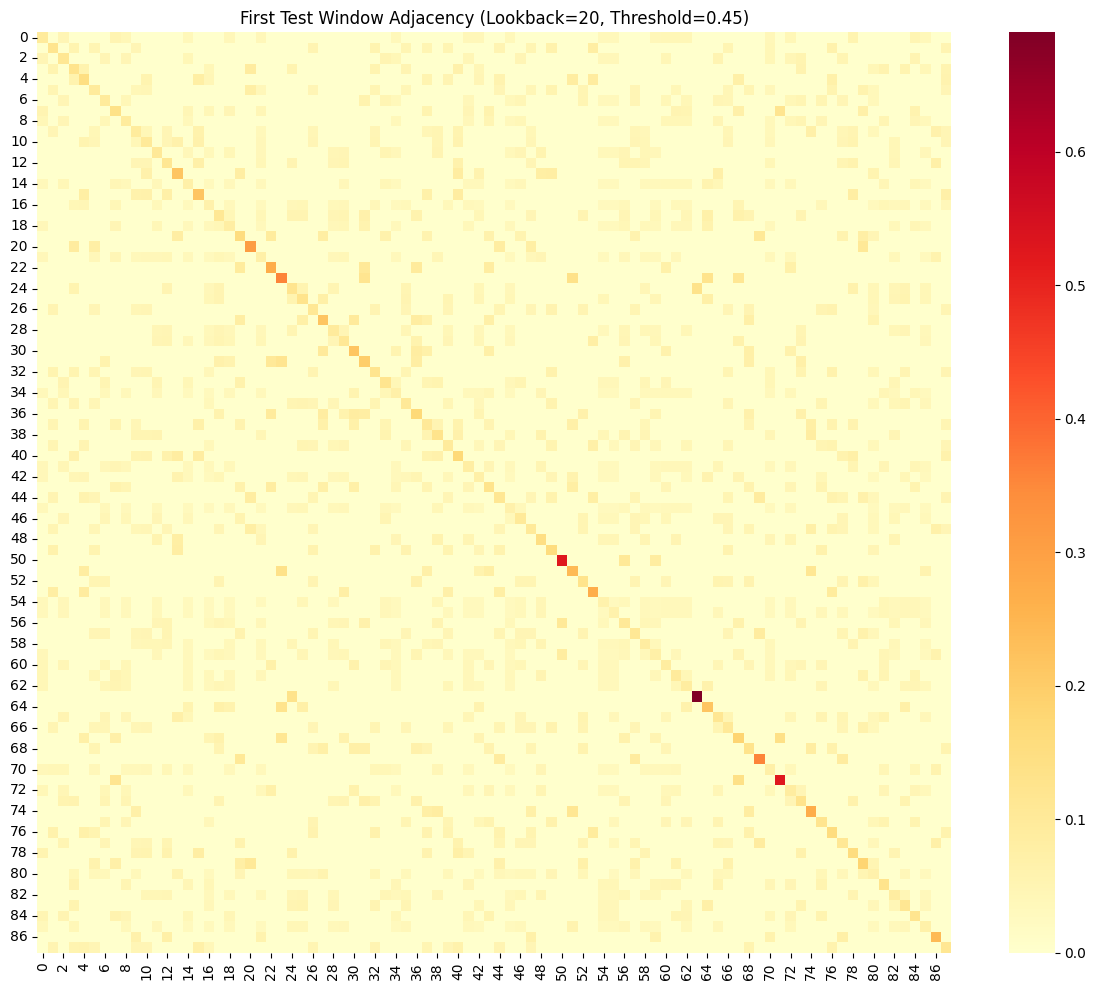

In [19]:
# Visualize first adjacency matrix
plot_adjacency_heatmap(
    test_data['adjacency'][0],
    f"First Test Window Adjacency (Lookback={CORRELATION_LOOKBACK}, Threshold={CORRELATION_THRESHOLD})"
)

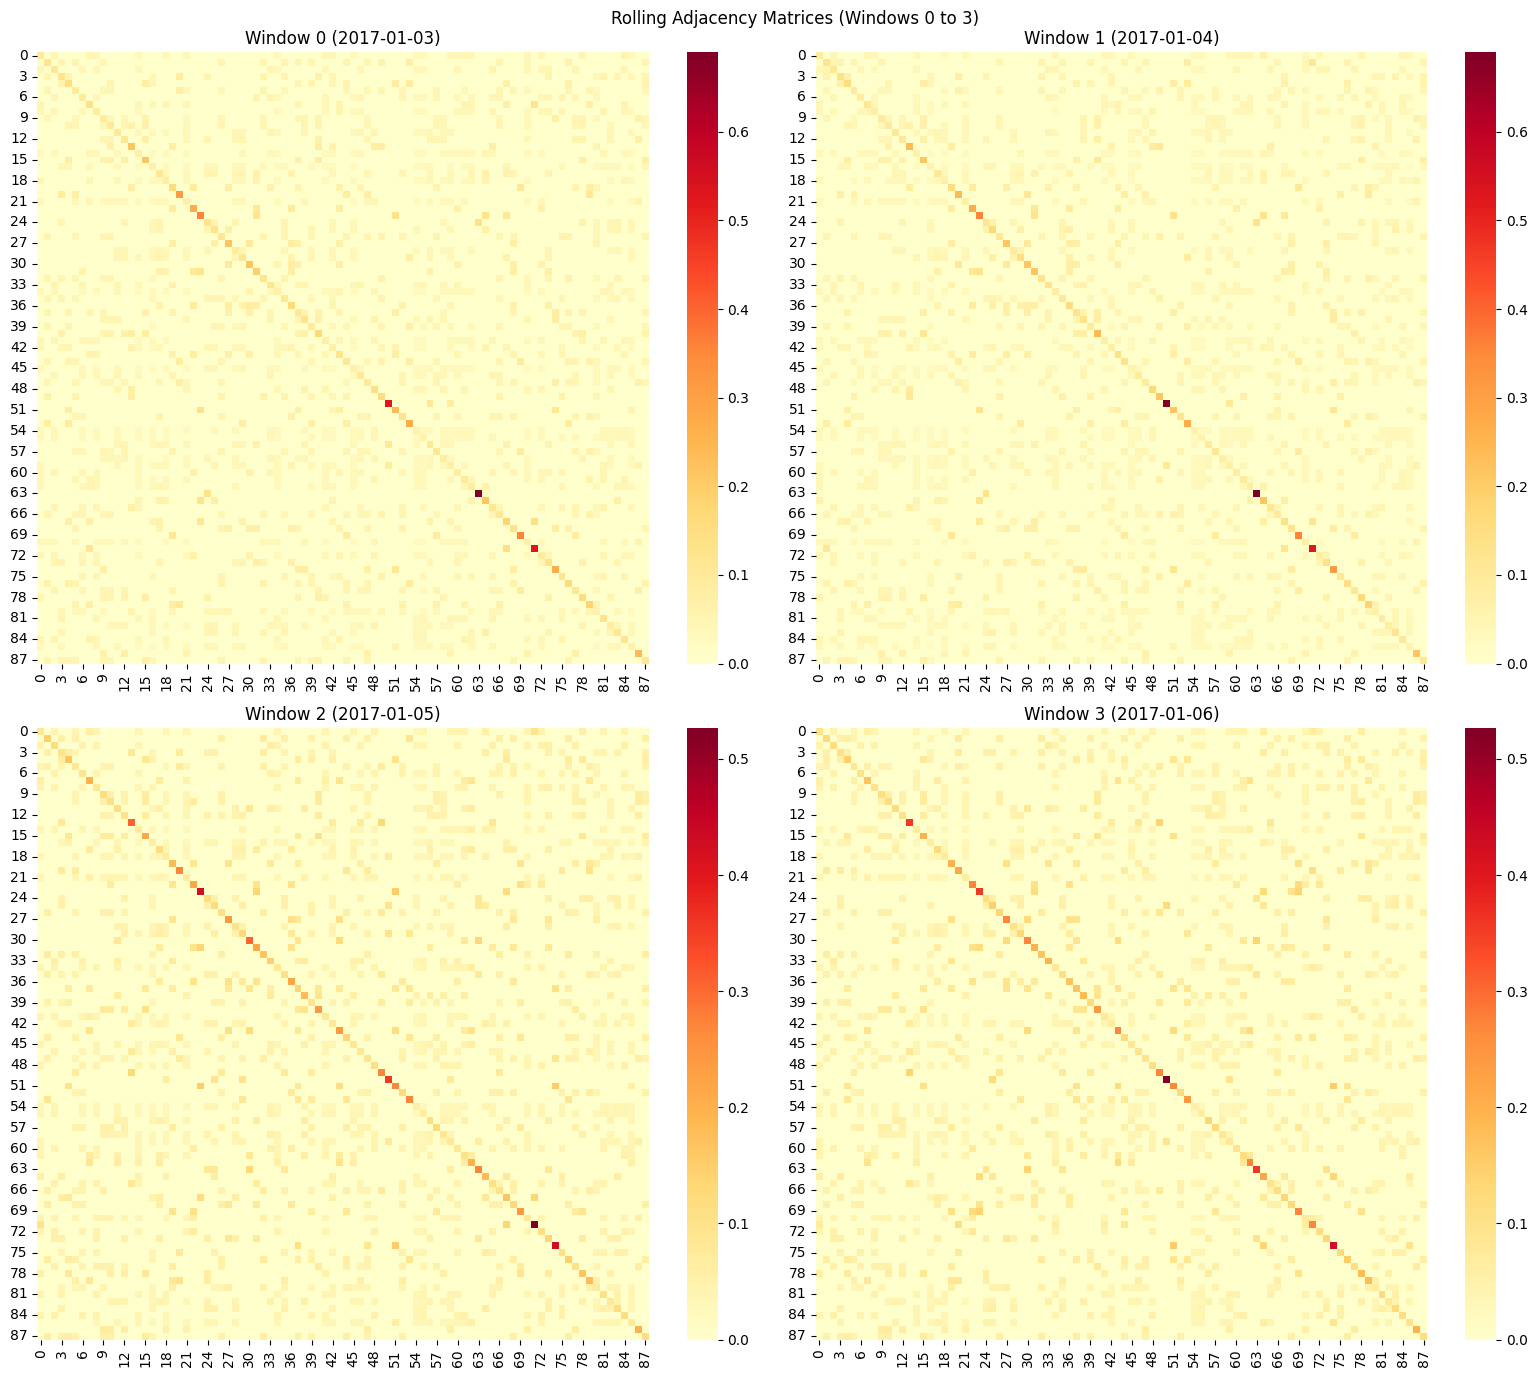

In [20]:
# Get window dates for visualization
test_dates = test_data['date'][:, 0, -1]  # Last date of each window
if test_dates.ndim > 1:
    test_dates = test_dates.squeeze()

# Plot 4 adjacent graphs
plot_adjacent_graphs(test_data['adjacency'], test_dates, start_idx=0)

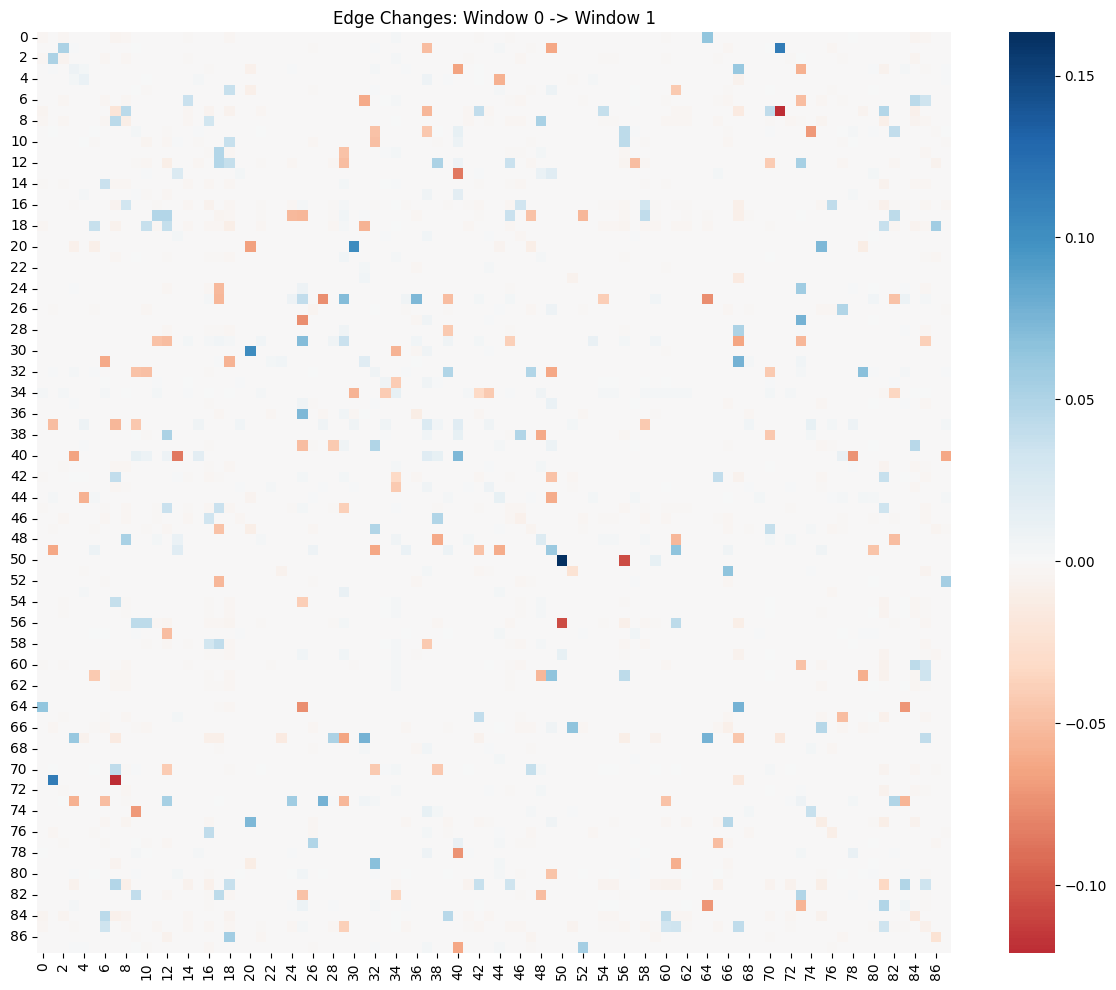

In [21]:
# Plot difference between first two graphs
plot_graph_diff(
    test_data['adjacency'][0],
    test_data['adjacency'][1],
    "Edge Changes: Window 0 -> Window 1"
)

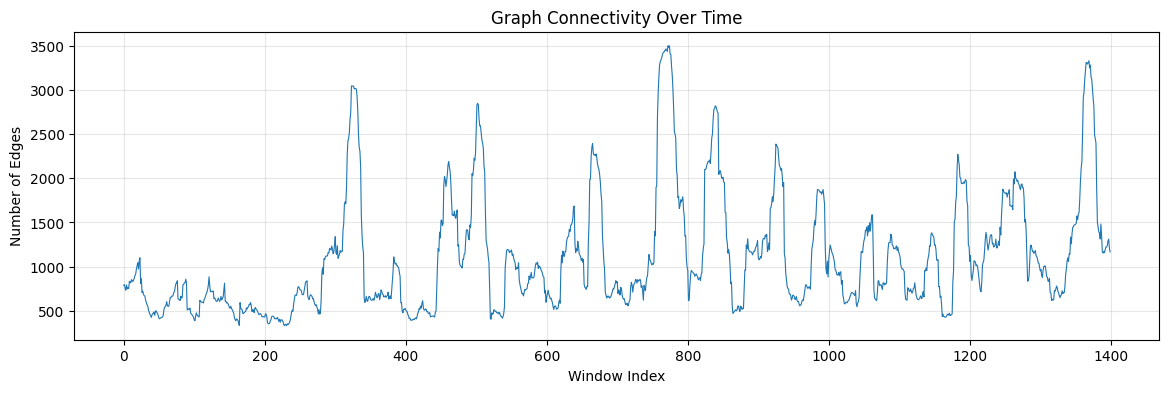

Edge statistics:
  Mean: 1104.3
  Std: 666.9
  Min: 331
  Max: 3500


In [22]:
# Plot edge statistics over time
plot_edge_statistics(test_data['adjacency'])

Zooming into windows 100 to 103
Date range: 2017-06-05 to 2017-06-08


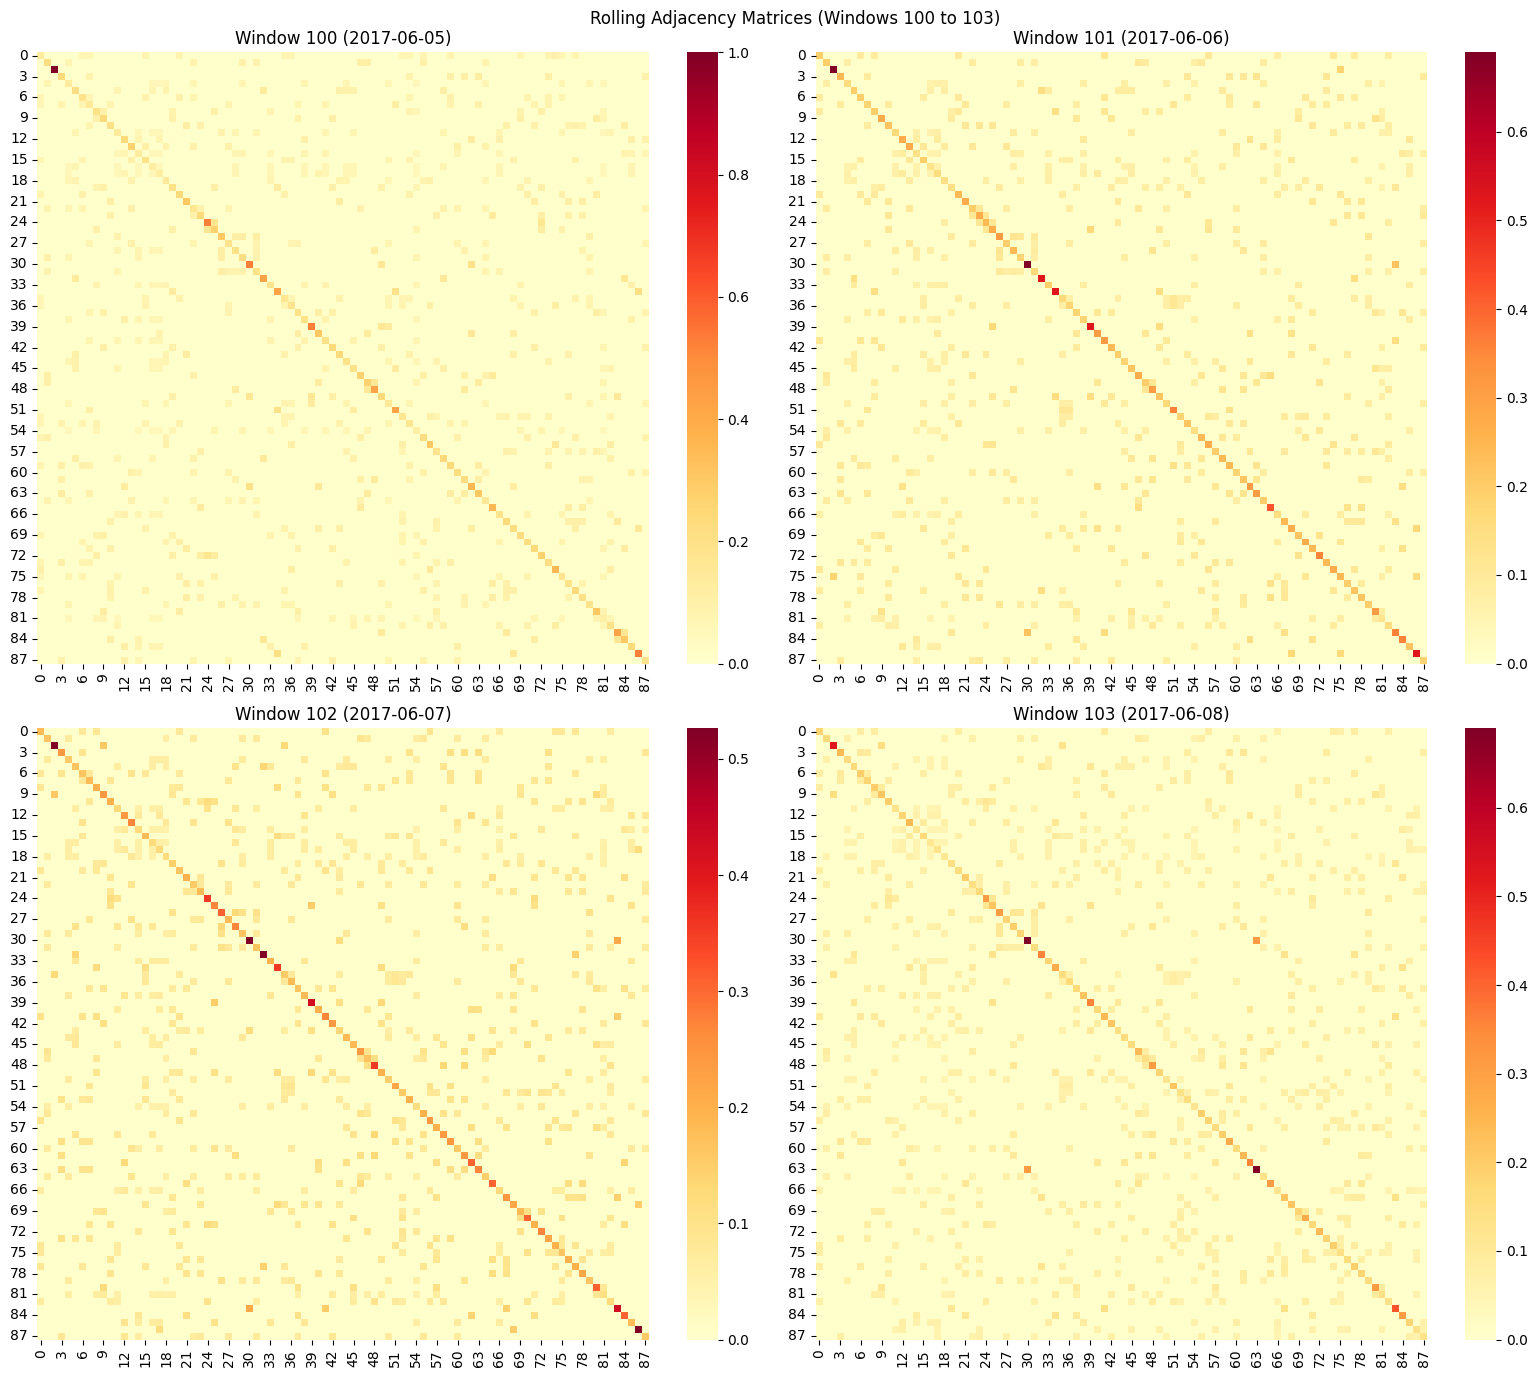

In [23]:
# Interactive zoom: specify window range
# Example: Zoom into a specific period
ZOOM_START = 100  # Change this to explore different periods

print(f"Zooming into windows {ZOOM_START} to {ZOOM_START + 3}")
print(f"Date range: {test_dates[ZOOM_START]} to {test_dates[min(ZOOM_START + 3, len(test_dates) - 1)]}")

plot_adjacent_graphs(test_data['adjacency'], test_dates, start_idx=ZOOM_START)

## 9. Save Results

In [24]:
# Create results directory
results_dir = f"results/lstm_gcn_rolling_pearson_lb{CORRELATION_LOOKBACK}_th{CORRELATION_THRESHOLD}/{TEST_START}-{TEST_END}"
os.makedirs(results_dir, exist_ok=True)

# Save captured returns
results_df.to_csv(os.path.join(results_dir, "captured_returns_sw.csv"), index=False)

# Save metrics
metrics_df = pd.DataFrame([metrics_raw])
metrics_df.to_csv(os.path.join(results_dir, "metrics_raw.csv"), index=False)

metrics_norm_df = pd.DataFrame([metrics_norm])
metrics_norm_df.to_csv(os.path.join(results_dir, "metrics_vol_normalized.csv"), index=False)

# Save yearly Sharpes
yearly_df = pd.DataFrame(yearly_sharpes.items(), columns=['Year', 'Sharpe'])
yearly_df.to_csv(os.path.join(results_dir, "yearly_sharpes.csv"), index=False)

print(f"Results saved to: {results_dir}")

Results saved to: results/lstm_gcn_rolling_pearson_lb20_th0.45/2017-2023


## 10. Summary

In [25]:
print("="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"\nModel: LSTM-GCN with Rolling Pearson Graphs")
print(f"\nRolling Pearson Configuration:")
print(f"  Correlation lookback: {CORRELATION_LOOKBACK} time steps")
print(f"  Correlation threshold: {CORRELATION_THRESHOLD}")
print(f"\nTraining Period: {TRAIN_START} - {TEST_START}")
print(f"Test Period:     {TEST_START} - {TEST_END}")
print(f"\nPerformance (Raw):")
print(f"  Sharpe Ratio: {metrics_raw['Sharpe']:.3f}")
print(f"  Annual Return: {metrics_raw['E[Ret.]']:.2%}")
print(f"  Annual Volatility: {metrics_raw['Vol.']:.2%}")
print(f"  Sortino Ratio: {metrics_raw['Sortino']:.3f}")
print(f"  Max Drawdown: {metrics_raw['Max DD']:.2%}")

EXPERIMENT SUMMARY

Model: LSTM-GCN with Rolling Pearson Graphs

Rolling Pearson Configuration:
  Correlation lookback: 20 time steps
  Correlation threshold: 0.45

Training Period: 2011 - 2017
Test Period:     2017 - 2023

Performance (Raw):
  Sharpe Ratio: 1.135
  Annual Return: 50.12%
  Annual Volatility: 44.78%
  Sortino Ratio: 1.550
  Max Drawdown: 51.79%


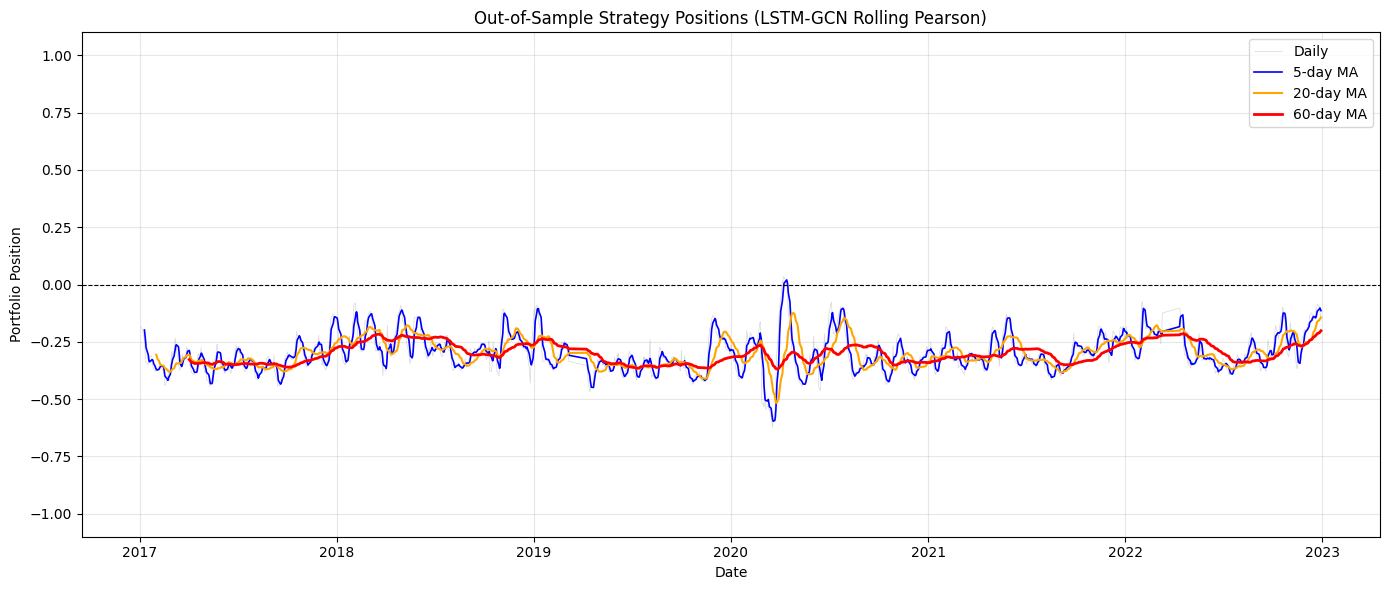

In [26]:
# Figure: Out-of-sample strategy positions at portfolio level
portfolio_pos = results_df.groupby('time')['position'].mean().sort_index()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(portfolio_pos.index, portfolio_pos.values,
        linewidth=0.5, alpha=0.3, color='gray', label='Daily')
ax.plot(portfolio_pos.rolling(5).mean(), linewidth=1.2, color='blue', label='5-day MA')
ax.plot(portfolio_pos.rolling(20).mean(), linewidth=1.5, color='orange', label='20-day MA')
ax.plot(portfolio_pos.rolling(60).mean(), linewidth=2.0, color='red', label='60-day MA')

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Position')
ax.set_title('Out-of-Sample Strategy Positions (LSTM-GCN Rolling Pearson)')
ax.legend(loc='upper right')
ax.set_ylim(-1.1, 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# See if positive positions also capture returns
pos_mask = results_df['position'] > 0
neg_mask = results_df['position'] < 0

print(f"Positive positions: {pos_mask.sum()} ({pos_mask.mean():.1%})")
print(f"Negative positions: {neg_mask.sum()} ({neg_mask.mean():.1%})")
print(f"\nAvg captured return when positive: {results_df.loc[pos_mask, 'captured_returns'].mean():.6f}")
print(f"Avg captured return when negative: {results_df.loc[neg_mask, 'captured_returns'].mean():.6f}")

Positive positions: 175744 (7.2%)
Negative positions: 2271536 (92.8%)

Avg captured return when positive: -0.000004
Avg captured return when negative: 0.000110
